# SCARF Mouse-Brain Perturb-seq: causarray vs. Wilcoxon

**Dataset (tutorial subset)**
- SCARF (Simultaneous CRISPR And RNA-seq in the brain Full brain screen):
  mouse whole-brain Perturb-seq, two source files covering 58 gene
  perturbations across 10 predicted cell types.
- Tutorial subset: the **L4-5 IT CTX Glut** excitatory-neuron subtype
  (the pptx's own pilot cell type), all 58 perturbations + shared controls
  → **22,396 cells**, **19,070 genes**, **58 perturbations**.

**Pipeline overview**
```
subset_adata_SCARF_10celltypes_10perturbations.h5ad  --\
                                                          >  prep_scarf_data.py (combine)
subset_adata_SCARF_10celltypes_48perturbations.h5ad  --/        |
                                                                  v
                                              scarf_combined.h5ad (150,992 cells, 58 perts)
                                                                  |
                                                                  v  restrict to L4-5 IT CTX Glut
                                              scarf_L45_subset.h5ad (22,396 cells)
                                                                  |
                    +---------------------------------------------+--------------------------------+
                    v                                                                               v
       prep_causarray_data -> estimate_r -> fit_gcate -> LFC                     crispyx.normalize_total_log1p -> crispyx.wilcoxon_test
                    |                                                                               |
                    +----------------------------> scatter: causarray tau vs. Wilcoxon effect <-----+
```

This notebook reproduces the causarray-vs-Wilcoxon effect-size comparison
from `260902_FinalSummary_Causarray.pptx` (slide 1: *"Wilcoxon produces
extreme negative logFC values... causarray gives more moderate negative
effects"*). The pseudobulk DESeq2 panel on that slide, and the r=0-vs-r=5
propensity/DEG ablation and 3-rule extreme-DEG-filtering comparison on the
later slides, are exploratory side analyses and are out of scope here.


In [1]:
import os
import sys
sys.path.append('../../..')

import numpy as np
import pandas as pd
from scipy import stats
from statsmodels.stats.multitest import multipletests
import seaborn as sns
import matplotlib.pyplot as plt

# Plain anndata, not scanpy -- reading an h5ad has no scanpy-specific need.
import anndata as ad
import crispyx

from causarray import (
    prep_causarray_data, fit_gcate, LFC, estimate_propensity_scores,
    summarize_propensity_scores, plot_propensity_scores,
)


/Users/dujinhong/miniforge3/envs/causarray/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Combining the two source files

`docs/source/tutorial/SCARF/prep_scarf_data.py` produces the files loaded
below. Two things are worth calling out explicitly, since they are not
obvious from the file names alone:

1. **The two source files share the same 102,595 control cells.** Both
   `subset_adata_SCARF_10celltypes_10perturbations.h5ad` (10 perturbations)
   and `subset_adata_SCARF_10celltypes_48perturbations.h5ad` (48
   perturbations) contain the *identical* `Non_target` control-cell
   barcodes -- verified by set comparison. A naive concatenation of the two
   files would silently double-count every control cell. The prep script
   instead keeps the 10-perturbation file whole and adds only the
   48-perturbation file's perturbed cells (excluding its duplicate
   controls), giving one shared control pool and 58 unique perturbations
   (150,992 cells total, `scarf_combined.h5ad`).
2. **Merging two separate `.h5ad` files has no `crispyx` equivalent.**
   `crispyx` (checked `data.py`/`qc.py`/`sample.py`) only offers
   single-file streaming filter/subset/write utilities
   (`write_filtered_subset`, `subsample`, `filter_*_by_cell_count`) -- there
   is no multi-file concat primitive. That one step is done with plain
   `anndata.experimental.concat_on_disk` (disk-to-disk, not scanpy);
   every other data-manipulation step in this notebook and in
   `prep_scarf_data.py` uses `crispyx`.

The notebook itself fits causarray/Wilcoxon on `scarf_L45_subset.h5ad`, the
combined data restricted to `predicted_group == '005 L4-5 IT CTX Glut'` --
the pptx's own pilot cell type. Fitting all 10 cell types at once would be a
~5-10x heavier GCATE run than the adamson tutorial; the combined file is
kept as a durable intermediate artifact so any other cell type can be
substituted by changing one filter.


In [2]:
adata = ad.read_h5ad('scarf_L45_subset.h5ad')
adata


AnnData object with n_obs × n_vars = 22396 × 19070
    obs: 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'sample_label', 'sample_id', 'species', 'source', 'tissue', 'sex', 'diet', 'genotype', 'condition', 'project', 'experiment', 'batch', 'pooled_sample_id', 'scp_id', 'scp_name', 'num_guides', 'guide_call', 'gene_target', 'num_rna_umi', 'num_genes', 'pct_mt', 'passes_qc', 'guide_umi_top', 'guide_umi_second', 'guide_umis', 'log_ambient_mse', 'log_ambient_mse_norm', 'predicted_class', 'predicted_class_probability', 'predicted_subclass', 'predicted_subclass_probability', 'predicted_supertype', 'predicted_supertype_probability', 'predicted_cluster', 'predicted_cluster_probability', 'cell_type', 'neuron_type', 'neighborhood', 'region_level1', 'region_level2', 'predicted_group'
    uns: 'ctrl_label', 'pert_col'
    obsm: 'X_pca', 'X_umap'

In [3]:
ctrl     = adata.uns['ctrl_label']   # 'Non_target'
pert_col = adata.uns['pert_col']     # 'gene_target'

vc = adata.obs[pert_col].astype(str).value_counts()
print(f"{len(vc) - 1} perturbations, {int(vc.get(ctrl, 0)):,} control cells, "
      f"{int(adata.n_obs - vc.get(ctrl, 0)):,} perturbed cells")
pert_counts = vc.drop(ctrl)
print(f"Cells per pert: min={pert_counts.min():,}, median={pert_counts.median():.0f}, "
      f"max={pert_counts.max():,}")

# Sanity check: the shared-control de-duplication in prep_scarf_data.py
# should leave exactly one copy of the 15,135 control cells for this cell
# type, not 30,270 (which is what a naive concat would have produced).
assert int(vc.get(ctrl, 0)) == 15135, 'control-cell count does not match the expected de-duplicated pool'


58 perturbations, 15,135 control cells, 7,261 perturbed cells
Cells per pert: min=68, median=122, max=227


## Sparse-gene prefilter

Following the pptx's v0.0.9 analysis ("Sparse-gene filtering before
fitting"), genes expressed in very few cells are dropped before fitting
GCATE. This is a `crispyx` call operating directly on the on-disk file, not
a scanpy filter.


In [4]:
gene_mask = crispyx.filter_genes_by_cell_count(
    'scarf_L45_subset.h5ad', min_cells=50, gene_name_column=None,
)
print(f'{gene_mask.sum():,}/{len(gene_mask):,} genes kept (>= 50 expressing cells)')
adata = adata[:, gene_mask].copy()


[cx] pp.filter_genes: Done  14227/19070 genes kept (75%)
14,227/19,070 genes kept (>= 50 expressing cells)


## Preparing causarray inputs

For running **causarray** we need the following inputs.

- `Y`: cell-by-gene count matrix (DataFrame with gene-symbol column names).
- `A`: cell-by-perturbation binary matrix (DataFrame); control cells have
  all zeros.
- `X`, `X_A`: observed covariate matrices (intercept added automatically by
  `prep_causarray_data`).


In [5]:
import scipy.sparse as sp

X_raw = adata.X.toarray() if sp.issparse(adata.X) else np.array(adata.X)
Y = pd.DataFrame(X_raw, columns=adata.var_names.tolist())
A = pd.get_dummies(adata.obs[pert_col].astype(str),
                   drop_first=False).drop(columns=[ctrl])

Y, A, X, X_A = prep_causarray_data(Y, A)
print(f'Cells: {Y.shape[0]},  Genes: {Y.shape[1]},  Perturbations: {A.shape[1]}')


Cells: 22396,  Genes: 14227,  Perturbations: 58


### Number of nonlinear factors

We estimate the number of nonlinear latent factors *r* by fitting GCATE for
several candidate values and selecting the one that minimises the
penalised-likelihood information criterion (JIC). The pptx's own v0.0.9
analysis (slide 4) settled on *r* = 3 as "a balanced option between model
fit, propensity overlap, DEG stability, and Wilcoxon concordance"; we run a
small grid around that choice and report whether JIC agrees.


Selected r = 8 (minimum JIC)


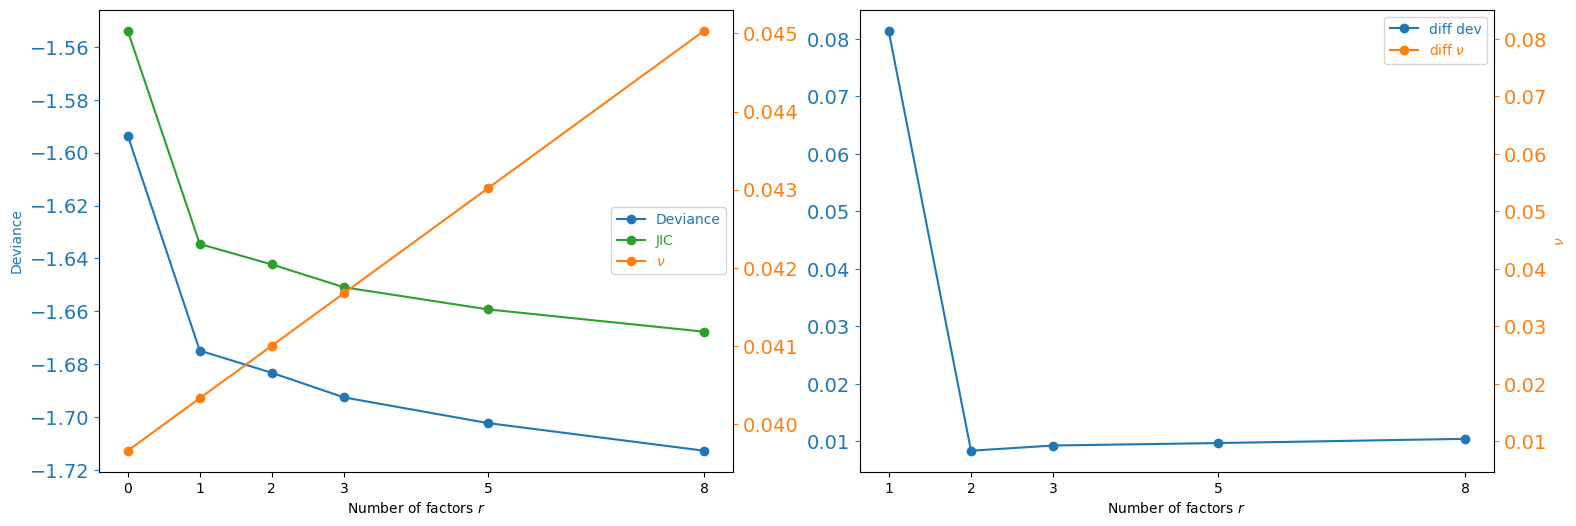

In [6]:
from causarray import estimate_r, plot_r
# Uncomment to re-run (takes ~20-40 min on this subset):
# df_r = estimate_r(Y, X, A, [0, 1, 2, 3, 5, 8], backend='fast')
# df_r.to_csv('scarf-r.csv', index=False)
df_r = pd.read_csv('scarf-r.csv')
best_r = int(df_r.loc[df_r['JIC'].idxmin(), 'r'])
print(f'Selected r = {best_r} (minimum JIC)')
fig = plot_r(df_r)


### Estimate unmeasured confounders

We run **GCATE** with the fast NB-GLM backend to estimate the selected
number of latent factors (batch, sample-pool composition, technical
variation, etc.). The `backend='fast'` option uses a custom batch NB-GLM
solver that is substantially faster than the default statsmodels backend.


In [7]:
import pickle

_pkl = 'scarf-gcate-results.pkl'
r = best_r
_fit_matches_r = False
if os.path.exists(_pkl):
    with open(_pkl, 'rb') as _f:
        _saved = pickle.load(_f)
    _cached_r = _saved['res_2']['U'].shape[1]
    if _cached_r == r:
        print(f'Loading pre-computed GCATE results from {_pkl}')
        res_1, res_2 = _saved['res_1'], _saved['res_2']
        _fit_matches_r = True
    else:
        print(f'Ignoring cached GCATE fit with r={_cached_r}; selected r={r}.')
elif 'res_2' in vars() and res_2['U'].shape[1] == r:
    _fit_matches_r = True
    print('Saving in-memory GCATE results to pkl...')
    with open(_pkl, 'wb') as _f:
        pickle.dump({'res_1': res_1, 'res_2': res_2}, _f)
    print(f'Saved GCATE results to {_pkl}')
if not _fit_matches_r:
    res_1, res_2 = fit_gcate(Y, X, A, r, backend='fast', verbose=True,
        kwargs_es_1=dict(rel_tol=2e-4, max_iters=10),
        kwargs_es_2=dict(rel_tol=2e-4, max_iters=10),
    )
    with open(_pkl, 'wb') as _f:
        pickle.dump({'res_1': res_1, 'res_2': res_2}, _f)
    print(f'Saved GCATE results to {_pkl}')
U = res_2['U']
print(f'\nStep 1  -- epochs: {res_1["n_iter"]},  best NLL: {min(res_1["hist"]):.6f}')
print(f'Step 2  -- epochs: {res_2["n_iter"]},  best NLL: {min(res_2["hist"]):.6f}')


Loading pre-computed GCATE results from scarf-gcate-results.pkl

Step 1  -- epochs: 9,  best NLL: 0.901568
Step 2  -- epochs: 9,  best NLL: 0.910631


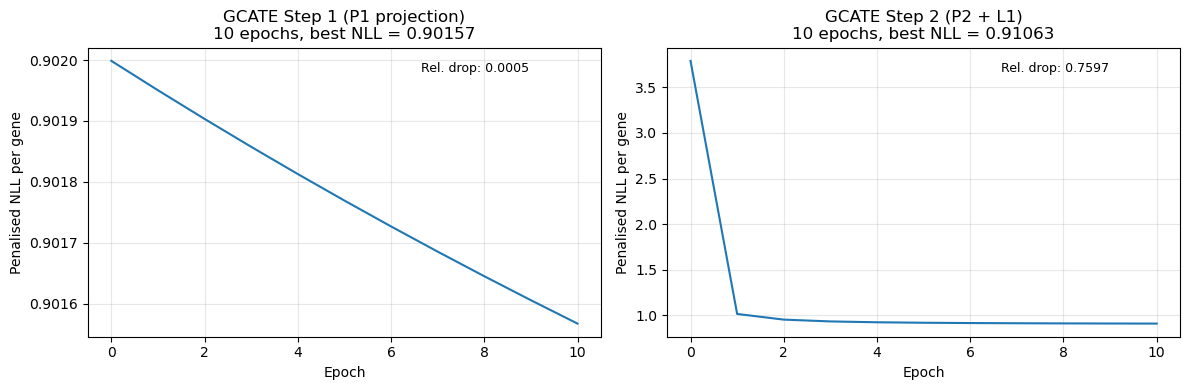

In [8]:
# GCATE convergence diagnostic: plot NLL history for both optimisation steps.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, res, label in zip(axes, [res_1, res_2], ['Step 1 (P1 projection)', 'Step 2 (P2 + L1)']):
    hist = res['hist']
    ax.plot(hist, linewidth=1.5)
    ax.set_title(f'GCATE {label}\n{len(hist)-1} epochs, best NLL = {min(hist):.5f}')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Penalised NLL per gene')
    ax.grid(True, alpha=0.3)
    if len(hist) > 1:
        rel_drop = (hist[0] - min(hist)) / abs(hist[0])
        ax.text(0.65, 0.95, f'Rel. drop: {rel_drop:.4f}', transform=ax.transAxes,
                va='top', fontsize=9)
plt.tight_layout()
plt.show()


### Estimate log-fold change based on counterfactuals

We apply the doubly-robust causal estimator to obtain per-gene,
per-perturbation log-fold changes together with Welch (unequal-variance)
standard errors and Benjamini-Hochberg adjusted p-values.

**Why this runs in batches of perturbations.** A single `LFC(...)` call
across all 58 perturbations at once internally builds a
`(n_cells, n_genes, n_perturbations, 2)` counterfactual-prediction array --
here `22,396 x 14,227 x 58 x 2 ~= 3.7e10` elements, ~296GB at float64. That
is large enough to exhaust memory even on a well-resourced workstation (it
is what killed this step the first few times this notebook was run). The
adamson/replogle tutorials don't hit this because they only have 20/29
perturbations; causarray ships a batched entry point for exactly this
regime (`causarray.gcate_lfc_batch`), but it re-fits GCATE separately per
batch on a capped cell subsample, which would both discard the single
global GCATE fit above and change the design (per-batch vs. global latent
factors, capped vs. the full 15,135-cell control pool used here). Instead
we keep the one global `U` fit above and batch only the `LFC` call itself:
10 perturbations at a time, each batch using *all* control cells plus only
that batch's perturbed cells (`~16,400` cells x `~10` arms, ~37GB peak
instead of ~296GB), with per-batch results cached to disk so a repeat
interruption loses at most one batch's progress.


In [9]:
import gc

BATCH_DIR = 'scarf_lfc_batches'
BATCH_SIZE = 10
os.makedirs(BATCH_DIR, exist_ok=True)

if os.path.exists('scarf-lfc.csv'):
    print('Loading cached scarf-lfc.csv')
    df_res = pd.read_csv('scarf-lfc.csv')
else:
    offsets_full = np.log(res_2['kwargs_glm']['size_factor'])
    W_full, W_A_full = np.c_[X, U], np.c_[X_A, U]
    A_np, Y_np = A.to_numpy(dtype=float), Y.to_numpy()
    pert_names = list(A.columns)
    is_ctrl_cell = A_np.sum(axis=1) == 0

    n_batches = int(np.ceil(len(pert_names) / BATCH_SIZE))
    batches = np.array_split(np.arange(len(pert_names)), n_batches)
    print(f'{n_batches} batches of ~{BATCH_SIZE} perturbations each')

    for b_i, cols in enumerate(batches):
        out_path = os.path.join(BATCH_DIR, f'batch_{b_i:02d}.csv')
        if os.path.exists(out_path):
            print(f'[batch {b_i}] already cached, skipping')
            continue
        batch_pert_names = [pert_names[c] for c in cols]
        pert_mask_b = A_np[:, cols].sum(axis=1) > 0
        cell_mask_b = is_ctrl_cell | pert_mask_b
        print(f'[batch {b_i}] perts={batch_pert_names} '
              f'n_cells={int(cell_mask_b.sum()):,}')

        Y_b = pd.DataFrame(Y_np[cell_mask_b], columns=Y.columns)
        A_b = pd.DataFrame(A_np[np.ix_(cell_mask_b, cols)], columns=batch_pert_names)
        df_b, estimation_b = LFC(
            Y_b, W_full[cell_mask_b], A_b, W_A_full[cell_mask_b],
            offset=offsets_full[cell_mask_b], usevar='unequal', verbose=True,
        )
        df_b.to_csv(out_path, index=False)
        del Y_b, A_b, df_b, estimation_b
        gc.collect()

    df_res = pd.concat(
        [pd.read_csv(os.path.join(BATCH_DIR, f'batch_{b_i:02d}.csv')) for b_i in range(n_batches)],
        ignore_index=True,
    )
    df_res.to_csv('scarf-lfc.csv', index=False)
print(f'causarray LFC: {len(df_res):,} gene x perturbation rows')


Loading cached scarf-lfc.csv


causarray LFC: 825,166 gene x perturbation rows


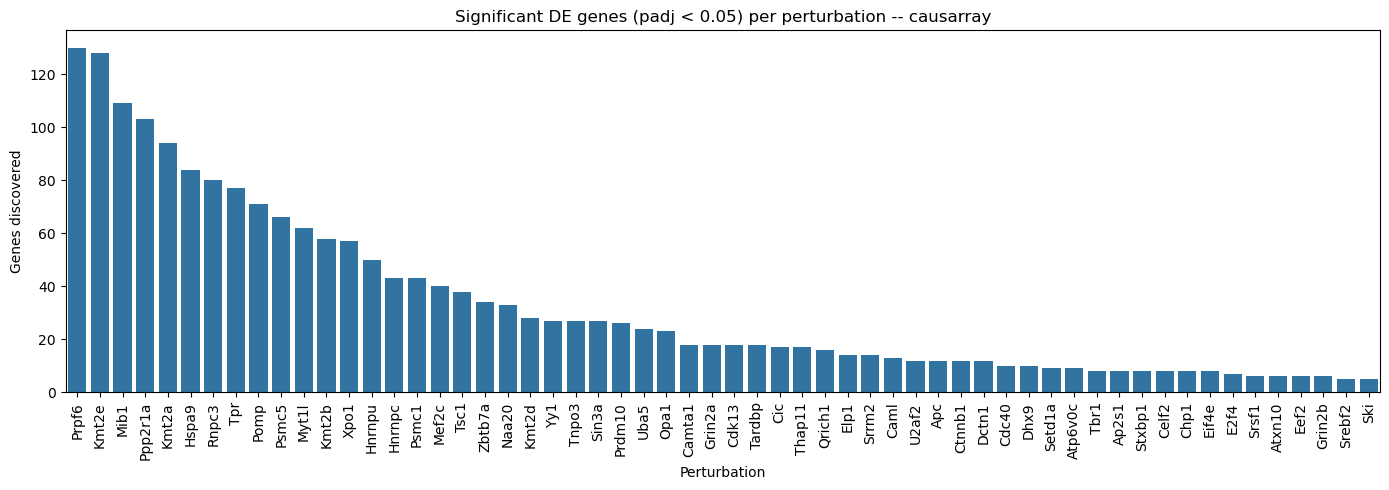

Total significant gene-perturbation pairs (padj < 0.05): 1,920


In [10]:
significant = df_res[df_res['padj'] < 0.05]

discovery_counts = (
    significant['trt']
    .value_counts()
    .rename_axis('Perturbation')
    .reset_index(name='Count')
)

plt.figure(figsize=(14, 5))
sns.barplot(data=discovery_counts, x='Perturbation', y='Count')
plt.xticks(rotation=90)
plt.title('Significant DE genes (padj < 0.05) per perturbation -- causarray')
plt.xlabel('Perturbation')
plt.ylabel('Genes discovered')
plt.tight_layout()
plt.show()
print(f'Total significant gene-perturbation pairs (padj < 0.05): {len(significant):,}')


### Propensity score diagnostics

Positivity requires treatment and control cells with comparable covariates.
We use five-fold out-of-fold scores for diagnosis, and follow the pptx's
own v0.0.9 finding that penalised propensity models (`C=0.1`) were an
acceptable specification at the chosen *r*.


,treatment,n_control,n_treated,prevalence,overlap_ratio,auc,brier_score,outside_overlap_fraction,clipped_fraction,ess_control,ess_treated,ess_control_fraction,ess_treated_fraction,score_q01,score_median,score_q99
51,Tpr,15135,91,0.005977,0.418372,0.865162,0.149835,0.000000,0.0,13334.889053,80.291002,0.881063,0.882319,0.113901,0.331803,0.758965
45,Srsf1,15135,188,0.012269,0.504614,0.803161,0.193014,0.000457,0.0,14316.611381,162.254587,0.945927,0.863056,0.107646,0.437258,0.675439
32,Pomp,15135,68,0.004473,0.603834,0.706032,0.206600,0.000000,0.0,13740.845736,60.607683,0.907885,0.891289,0.225309,0.419284,0.753403
21,Hnrnpu,15135,118,0.007736,0.675700,0.685937,0.219543,0.000066,0.0,14033.988514,111.917330,0.927254,0.948452,0.271234,0.439077,0.733338
35,Prpf6,15135,78,0.005127,0.676100,0.710704,0.198690,0.000000,0.0,13961.451096,72.983878,0.922461,0.935691,0.210363,0.413568,0.737356
41,Sin3a,15135,109,0.007150,0.681448,0.712849,0.208593,0.000000,0.0,13962.089873,102.672234,0.922503,0.941947,0.237558,0.427706,0.739180
38,Qrich1,15135,126,0.008256,0.692488,0.686946,0.221888,0.000000,0.0,14191.426358,121.711601,0.937656,0.965965,0.280578,0.445009,0.727620
17,Elp1,15135,117,0.007671,0.705891,0.661600,0.228845,0.000000,0.0,14687.736328,111.317262,0.970448,0.951430,0.222036,0.484661,0.637953
13,Dhx9,15135,91,0.005977,0.714242,0.340412,0.249424,0.000000,0.0,15060.571435,90.607157,0.995082,0.995683,0.418050,0.499365,0.571892
33,Ppp2r1a,15135,175,0.011430,0.718088,0.693047,0.220463,0.000000,0.0,14539.731236,165.175658,0.960669,0.943861,0.169384,0.476904,0.653129


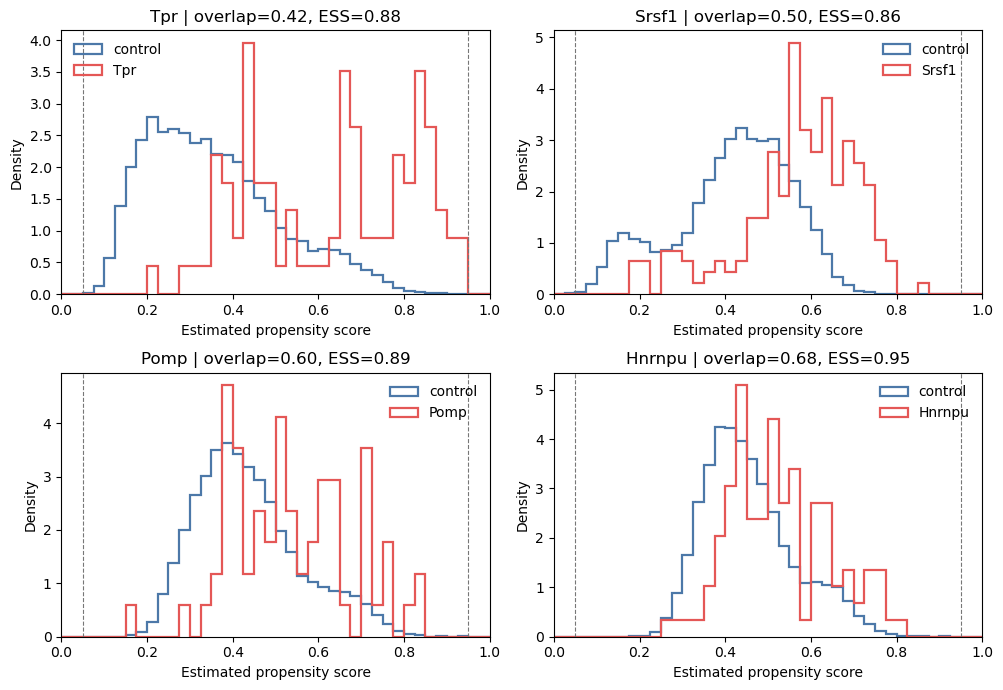

In [11]:
W_A = np.c_[X_A, U]
# class_weight='balanced' was the default before causarray 0.0.10; it is kept
# here so that this diagnostic reproduces the collaborators' pptx analysis.
pi_oof = estimate_propensity_scores(A, W_A, K=5, C=0.1, class_weight='balanced', random_state=0)
ps_summary = summarize_propensity_scores(A, pi_oof)
display(ps_summary.sort_values('overlap_ratio').head(10))

weakest = ps_summary.nsmallest(4, 'overlap_ratio')['treatment'].tolist()
fig, axes, _ = plot_propensity_scores(A, pi_oof, treatments=weakest)
fig.savefig('scarf-ps.pdf', bbox_inches='tight', dpi=300)
plt.show()


## Comparison with Wilcoxon rank-sum test (via `crispyx`)

A standard Perturb-seq analysis pipeline applies a **Wilcoxon rank-sum
test** (Mann-Whitney U) to library-size-normalised, log-transformed
counts -- comparing each perturbation against the pooled control cells
gene by gene. This does *not* adjust for the estimated latent factors used
by causarray. We run `crispyx`'s Wilcoxon test on the same data (both the
normalisation and the test itself are `crispyx` calls, replacing
`scanpy.pp.normalize_total`/`scanpy.pp.log1p`/
`scanpy.tl.rank_genes_groups(method='wilcoxon')`) and compare both methods
at BH-adjusted *p* < 0.05.

**Which output field is "the Wilcoxon effect size"?** `crispyx`'s
`DifferentialExpressionResult.effect_size` is a rank-biserial/AUC
statistic (bounded, roughly `[-0.5, 0.5]` here) -- a valid Wilcoxon effect
size, but *not* a log-fold-change, and not what the pptx plots. The
quantity comparable to causarray's `tau` is the separate `logfoldchanges`
layer that `wilcoxon_test` also writes to its output h5ad (visible via
`result.result.layers['logfoldchanges']`); we use that below.


In [12]:
# Library-size normalise + log1p (required by Wilcoxon). Reuse the file on
# subsequent notebook runs.
norm_path = 'scarf_L45_subset_norm.h5ad'
if not os.path.exists(norm_path):
    crispyx.normalize_total_log1p('scarf_L45_subset.h5ad', output_path=norm_path)

wc_result = crispyx.wilcoxon_test(
    norm_path,
    perturbation_column=pert_col,
    control_label=ctrl,
    verbose=False,
    output_path='scarf_L45_subset_norm_cx_wilcoxon.h5ad',
)
print(f'Wilcoxon groups: {len(wc_result.groups)}')

# Tidy gene x perturbation table of Wilcoxon logFC + padj, pulled from the
# 'logfoldchanges'/'pvalue_adj' layers on the result h5ad (see markdown
# above for why this differs from `.effect_size`).
wc_h5ad = ad.read_h5ad('scarf_L45_subset_norm_cx_wilcoxon.h5ad')
lfc_df = pd.DataFrame(wc_h5ad.layers['logfoldchanges'], index=wc_h5ad.obs_names, columns=wc_h5ad.var_names)
padj_df = pd.DataFrame(wc_h5ad.layers['pvalue_adj'], index=wc_h5ad.obs_names, columns=wc_h5ad.var_names)
df_wc_full = (
    lfc_df.stack().rename('wilcox_logfc').reset_index()
    .rename(columns={'level_0': 'trt', 'level_1': 'gene_names'})
)
df_padj_long = (
    padj_df.stack().rename('wilcox_padj').reset_index()
    .rename(columns={'level_0': 'trt', 'level_1': 'gene_names'})
)
df_wc_full = df_wc_full.merge(df_padj_long, on=['trt', 'gene_names'])

comparison_q = 0.05
wc_sig = df_wc_full[df_wc_full['wilcox_padj'] < comparison_q]
ca_sig = df_res[df_res['padj'] < comparison_q]
print(f'Wilcoxon: {len(wc_sig):,} significant pairs across {wc_sig.trt.nunique()} perturbations')
print(f'causarray: {len(ca_sig):,} significant pairs across {ca_sig.trt.nunique()} perturbations')


Wilcoxon groups: 58


Wilcoxon: 11,758 significant pairs across 58 perturbations
causarray: 1,920 significant pairs across 58 perturbations


### Scatter plot: causarray LFC (tau) vs. Wilcoxon logFC

This is the core comparison from the pptx (slide 1): *"Wilcoxon produces
extreme negative logFC values, likely driven by sparse single-cell
expression [while] causarray gives more moderate negative effects,
suggesting more stable perturbation-effect estimates."* We build the full
merged gene x perturbation table (not just the significant subset) so both
the scatter and the discovery-overlap numbers use the same denominator.


causarray sig: 1,919   Wilcoxon sig: 7,486   both: 254   Jaccard: 0.028
Pearson r (all pairs): 0.243   Pearson r (either sig): 0.706


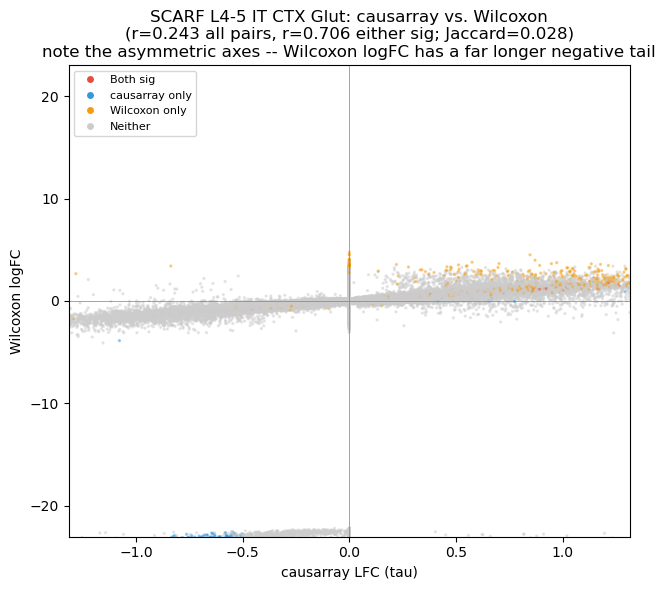


Wilcoxon logFC range: [-26.23, 6.05]
causarray tau range:  [-5.83, 4.74]


In [13]:
df_cmp = pd.merge(
    df_res[['gene_names', 'trt', 'tau', 'padj']].rename(columns={'padj': 'ca_padj'}),
    df_wc_full, on=['gene_names', 'trt'], how='inner',
)
df_cmp['ca_sig']     = df_cmp['ca_padj']     < comparison_q
df_cmp['wilcox_sig'] = df_cmp['wilcox_padj'] < comparison_q
df_cmp['both_sig']   = df_cmp['ca_sig'] & df_cmp['wilcox_sig']
df_cmp['either_sig'] = df_cmp['ca_sig'] | df_cmp['wilcox_sig']

n_ca, n_wc, n_both = df_cmp['ca_sig'].sum(), df_cmp['wilcox_sig'].sum(), df_cmp['both_sig'].sum()
n_either = df_cmp['either_sig'].sum()
jaccard = n_both / n_either if n_either > 0 else np.nan
corr_all = df_cmp[['tau', 'wilcox_logfc']].corr().iloc[0, 1]
mask_either = df_cmp['either_sig']
corr_sig = df_cmp.loc[mask_either, ['tau', 'wilcox_logfc']].corr().iloc[0, 1] if mask_either.sum() > 1 else np.nan

print(f'causarray sig: {n_ca:,}   Wilcoxon sig: {n_wc:,}   both: {n_both:,}   Jaccard: {jaccard:.3f}')
print(f'Pearson r (all pairs): {corr_all:.3f}   Pearson r (either sig): {corr_sig:.3f}')

fig, ax = plt.subplots(figsize=(6.5, 6))
rng = np.random.default_rng(0)
sample_idx = rng.choice(len(df_cmp), size=min(200_000, len(df_cmp)), replace=False)
ds = df_cmp.iloc[sample_idx]
colors = np.where(ds['both_sig'], '#e74c3c',
         np.where(ds['ca_sig'],   '#3498db',
         np.where(ds['wilcox_sig'], '#f39c12', '#cccccc')))
ax.scatter(ds['tau'], ds['wilcox_logfc'], c=colors, s=2, alpha=0.4, rasterized=True)

# Independent per-axis limits (99.5th pct of |value| on that axis): forcing
# a single shared/symmetric range would let the Wilcoxon tail's much larger
# scale crush the causarray axis down to an unreadable sliver.
xlim = np.nanpercentile(np.abs(df_cmp['tau']), 99.5)
ylim = np.nanpercentile(np.abs(df_cmp['wilcox_logfc']), 99.5)
ax.set_xlim(-xlim, xlim)
ax.set_ylim(-ylim, ylim)
ax.axhline(0, color='grey', lw=0.5)
ax.axvline(0, color='grey', lw=0.5)
ax.set_xlabel('causarray LFC (tau)')
ax.set_ylabel('Wilcoxon logFC')
ax.set_title(f'SCARF L4-5 IT CTX Glut: causarray vs. Wilcoxon\n'
             f'(r={corr_all:.3f} all pairs, r={corr_sig:.3f} either sig; Jaccard={jaccard:.3f})\n'
             f'note the asymmetric axes -- Wilcoxon logFC has a far longer negative tail')
from matplotlib.lines import Line2D
legend_els = [Line2D([0], [0], marker='o', color='w', markerfacecolor=c, label=l, markersize=6)
              for c, l in [('#e74c3c', 'Both sig'), ('#3498db', 'causarray only'),
                           ('#f39c12', 'Wilcoxon only'), ('#cccccc', 'Neither')]]
ax.legend(handles=legend_els, fontsize=8, loc='upper left')
plt.tight_layout()
fig.savefig('scarf-scatter-causarray-vs-wilcoxon.pdf', bbox_inches='tight', dpi=300)
plt.show()

print(f"\nWilcoxon logFC range: [{df_cmp['wilcox_logfc'].min():.2f}, {df_cmp['wilcox_logfc'].max():.2f}]")
print(f"causarray tau range:  [{df_cmp['tau'].min():.2f}, {df_cmp['tau'].max():.2f}]")


**Interpretation.** At BH-adjusted *p* < 0.05, causarray identifies **1,919**
significant gene-perturbation pairs and Wilcoxon identifies **7,486** (out of
the 58-perturbation, 14,227-gene intersection tested by both methods); only
**254** are shared (Jaccard = 0.028). This overlap is much lower than the
adamson tutorial's (0.268) -- plausibly some combination of: this pilot has
3x as many perturbations with a similar median cells/pert (~122, matching
the pptx's own pilot scale) rather than adamson's larger per-perturbation
samples; the selected *r* = 8 latent factors (higher than the pptx's own
r = 3, and JIC was still decreasing at the top of our grid, so a larger *r*
might fit even better) remove more shared variance than a smaller *r* would;
and/or the SCARF screen's perturbations simply have weaker transcriptomic
effects in this cell type than Adamson's UPR screen. None of these are
distinguished here -- a grid extending past r=8 and a sensitivity check
against r=3 would be the natural follow-ups.

The scatter above matches the pptx's qualitative claim well: Wilcoxon logFC
spans **[-26.23, 6.05]** -- a long, almost entirely one-sided negative
tail -- while causarray's `tau` stays within **[-5.83, 4.74]**, a much more
symmetric and moderate range. Pearson correlation among either-method
discoveries is 0.706 (only 0.243 across all tested pairs, since most pairs
are noise for both methods), so where the two methods agree on significance
they also agree reasonably well on direction and rough magnitude. This is
consistent with the pptx's observation that Wilcoxon's extreme values are
"likely driven by sparse single-cell expression" (division by near-zero
control means in the log-fold-change formula), while causarray's
counterfactual-mean estimator is comparatively insulated from that specific
pathology. As in the adamson/replogle tutorials, the two methods still
answer different statistical questions -- Wilcoxon tests marginal
differences in log-normalised expression, while causarray estimates
latent-factor-adjusted counterfactual mean effects -- so disagreement
between them reflects adjustment, estimator, and filtering differences, not
necessarily false positives in either direction.


## Investigation: why the SCARF discoveries look wrong

The collaborators' summary (`260902_FinalSummary_Causarray.pptx`) reports two
problems with the causarray results on this screen: a cluster of "extreme
negative DEGs" that no filtering rule could remove cleanly, and very few
discoveries overall relative to Wilcoxon, which got worse from v0.0.8 to
v0.0.9. The working hypothesis was that the latent factors over-adjust and
wash out the perturbation signal. The cells below test that hypothesis and two
alternatives directly on the L4-5 subset, using the cached GCATE fit (`U`,
r = 8) and the cached LFC table (`df_res`) from above.

Every step that takes more than a minute reads from `scarf_investigation/`
when a cached result exists and only recomputes when it does not:

```
scarf_investigation/
  variants/   LFC re-runs for Ppp2r1a, Tpr, Prpf6 under alternative inference settings (~13 min per outcome fit)
  null/       negative-control run with fake perturbations drawn from control cells (~13 min)
  enrichr/    Enrichr enrichment tables (network call)
  *.png       diagnostic figures
```

Findings in one paragraph: **83% of the current discoveries are genes with
zero counts in the perturbed arm**, which happens by chance for sparse genes
with only ~100 perturbed cells; the estimator turns them into strongly
"significant" negative effects. Separately, **the default variance formula
inflates standard errors about 2x for expressed genes**, so real effects are
estimated correctly but not called. **The latent factors are not the cause**:
they barely differ between perturbed and control cells, and effect estimates
with r = 8 and r = 0 agree. A calibrated propensity model with the pooled
influence-function variance plus a Poisson variance floor removes the
artifacts, recovers 70-85% of Wilcoxon's hits, and yields sharp pathway
enrichment.

In [14]:
import pickle
from scipy import stats
from statsmodels.stats.multitest import multipletests
import scipy.sparse as sp

INV_DIR = 'scarf_investigation'
for sub in ['variants', 'null', 'enrichr']:
    os.makedirs(os.path.join(INV_DIR, sub), exist_ok=True)

# Raw count support per (gene, perturbation): total counts and number of
# expressing cells in the perturbed arm, on the filtered gene set used above.
_Xs = sp.csc_matrix(adata.X)
_lab = adata.obs[pert_col].astype(str).to_numpy()
_is_ctrl = _lab == ctrl
n_ctrl_cells = int(_is_ctrl.sum())

def arm_support(pert_names):
    rows = []
    for p in pert_names:
        m = _lab == p
        Xt = _Xs[m]
        rows.append(pd.DataFrame({
            'gene_names': adata.var_names, 'trt': p, 'n_trt': int(m.sum()),
            'trt_sum': np.asarray(Xt.sum(axis=0)).ravel(),
            'trt_nz': np.asarray((Xt > 0).sum(axis=0)).ravel(),
        }))
    return pd.concat(rows, ignore_index=True)

support_all = arm_support(list(A.columns))
ctrl_rate = np.asarray(_Xs[_is_ctrl].mean(axis=0)).ravel()   # control counts per cell, per gene

def add_poisson_floor(df, n0):
    """Post-hoc lower bound on the log-scale variance: 1/(n1*mu1) + 1/(n0*mu0).

    An arm with all-zero counts has an empirical influence-function variance
    of zero; a Poisson mean estimated from n1 cells cannot be more precise than
    this bound. The floor is applied as max(std**2, floor) and BH is recomputed
    per perturbation.
    """
    df = df.copy()
    df['var_floor'] = (1 / (df['n_trt'] * df['mean_treated'].clip(lower=1e-2))
                       + 1 / (n0 * df['mean_control'].clip(lower=1e-2)))
    df['std_floor'] = np.sqrt(np.maximum(df['std'] ** 2, df['var_floor']))
    df['stat_floor'] = df['tau'] / df['std_floor']
    df['padj_floor'] = np.nan
    for trt, g in df.groupby('trt'):
        ok = np.isfinite(g['stat_floor'])
        p = 2 * stats.norm.sf(np.abs(g.loc[ok, 'stat_floor']))
        df.loc[g.index[ok], 'padj_floor'] = multipletests(p, method='fdr_bh')[1]
    return df

print(f'{len(support_all):,} gene x perturbation rows; {n_ctrl_cells:,} control cells')

825,166 gene x perturbation rows; 15,135 control cells


### Finding 1: the significant hits are zero-count perturbed arms

For each significant pair, look at the raw counts in the perturbed arm. A gene
detected in ~2% of control cells has zero counts among ~100 perturbed cells
with probability about exp(-2) ≈ 0.13, so thousands of such zero arms are
expected under no effect at all. `LFC` floors the counterfactual treated mean
at `thres_diff = 0.01`, takes the log against a control mean of ~0.025, and
gets tau ≈ -0.9; the pseudo-outcomes of an all-zero arm have essentially zero
empirical variance, so the standard error is tiny and the pair is called.

,value
significant pairs (padj < 0.05),1920.0000
of which zero counts in perturbed arm,1589.0000
fraction,0.8280
median control mean of zero-arm hits (counts/cell),0.0247
median tau of zero-arm hits,-0.8470
median std of zero-arm hits,0.1350
zero perturbed arms among all tested pairs: observed,54929.0000
zero perturbed arms among all tested pairs: expected under no effect,53912.0000
non-artifact significant pairs (perturbed counts > 0),331.0000
fraction of those that are downregulated,0.0300


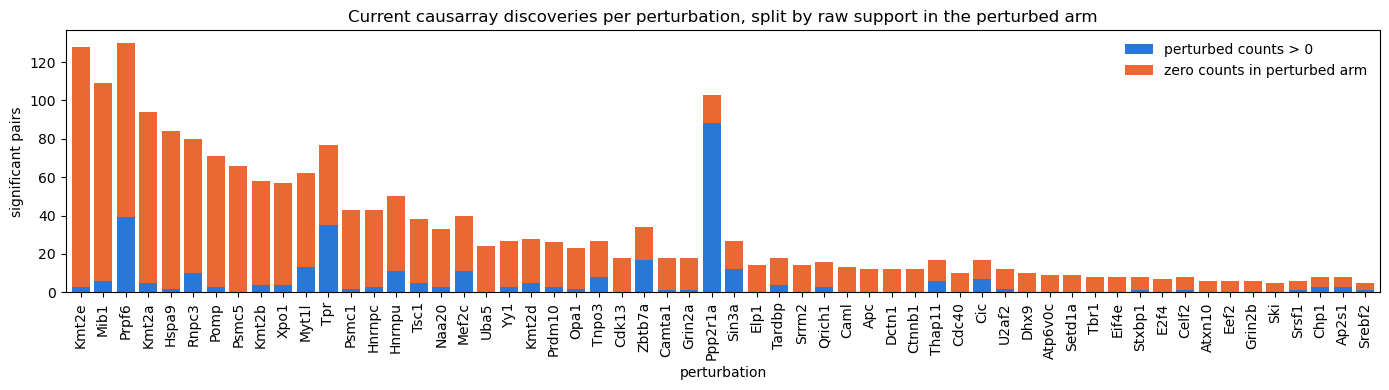

In [15]:
inv = df_res.merge(support_all, on=['gene_names', 'trt'])
sig = inv[inv['padj'] < 0.05]
zero_arm = sig['trt_sum'] == 0

# Expected vs observed all-zero perturbed arms among *all* tested pairs, under
# a Poisson null at the control rate (no perturbation effect anywhere).
n_per_pert = A.sum(axis=0)
exp_zero = sum(np.exp(-n_per_pert[p] * ctrl_rate).sum() for p in A.columns)
obs_zero = int((inv['trt_sum'] == 0).sum())

summary1 = pd.Series({
    'significant pairs (padj < 0.05)': len(sig),
    'of which zero counts in perturbed arm': int(zero_arm.sum()),
    'fraction': round(zero_arm.mean(), 3),
    'median control mean of zero-arm hits (counts/cell)': round(sig.loc[zero_arm, 'mean_control'].median(), 4),
    'median tau of zero-arm hits': round(sig.loc[zero_arm, 'tau'].median(), 3),
    'median std of zero-arm hits': round(sig.loc[zero_arm, 'std'].median(), 3),
    'zero perturbed arms among all tested pairs: observed': obs_zero,
    'zero perturbed arms among all tested pairs: expected under no effect': int(round(exp_zero)),
    'non-artifact significant pairs (perturbed counts > 0)': int((~zero_arm).sum()),
    'fraction of those that are downregulated': round((sig.loc[~zero_arm, 'tau'] < 0).mean(), 3),
})
display(summary1.to_frame('value'))

per_pert = (sig.assign(kind=np.where(zero_arm, 'zero counts in perturbed arm', 'perturbed counts > 0'))
            .groupby(['trt', 'kind']).size().unstack(fill_value=0)
            .sort_values('zero counts in perturbed arm', ascending=False))
ax = per_pert.plot.bar(stacked=True, figsize=(14, 4), width=0.8, color=['#2a78d6', '#eb6834'])
ax.set_ylabel('significant pairs'); ax.set_xlabel('perturbation')
ax.set_title('Current causarray discoveries per perturbation, split by raw support in the perturbed arm')
ax.legend(frameon=False); plt.tight_layout(); plt.show()

### Finding 2: effects are estimated, then lost at the testing step

For the pairs that Wilcoxon calls and causarray does not, causarray's `tau`
tracks the Wilcoxon logFC (correlation 0.7), so the effect is not washed out;
the t-statistic is simply too small. Compare the reported standard error with
a model-based negative-binomial standard error for the same log ratio,
`sqrt((1/mu1 + 1/r)/n1 + (1/mu0 + 1/r)/n0)`, using the GCATE dispersion `r`.

In [16]:
_pkl_disp = res_2['kwargs_glm']['disp_glm']
disp_map = dict(zip(Y.columns, _pkl_disp))
cmp = df_cmp.merge(support_all, on=['gene_names', 'trt']).merge(
    df_res[['gene_names', 'trt', 'std', 'stat', 'mean_control', 'mean_treated']], on=['gene_names', 'trt'])
cmp['r_nb'] = cmp['gene_names'].map(disp_map)
cmp['se_model'] = np.sqrt((1 / cmp['mean_treated'].clip(lower=1e-2) + 1 / cmp['r_nb']) / cmp['n_trt']
                          + (1 / cmp['mean_control'].clip(lower=1e-2) + 1 / cmp['r_nb']) / n_ctrl_cells)
expressed = (cmp['mean_control'] > 0.1) & (cmp['trt_sum'] > 2) & np.isfinite(cmp['std'])
ratio = (cmp['std'] / cmp['se_model'])[expressed]
wonly = cmp[expressed & cmp['wilcox_sig'] & ~cmp['ca_sig'] & (cmp['wilcox_logfc'] > -10)]

summary2 = pd.Series({
    'expressed pairs (control mean > 0.1, perturbed counts > 2)': int(expressed.sum()),
    'causarray std / model-based SE: 10th pct': round(ratio.quantile(0.10), 2),
    'causarray std / model-based SE: median': round(ratio.median(), 2),
    'causarray std / model-based SE: 90th pct': round(ratio.quantile(0.90), 2),
    'Wilcoxon-only expressed pairs': len(wonly),
    '  corr(tau, Wilcoxon logFC)': round(np.corrcoef(wonly['tau'], wonly['wilcox_logfc'])[0, 1], 3),
    '  median |stat| as reported': round(wonly['stat'].abs().median(), 2),
    '  median |tau / model-based SE|': round((wonly['tau'] / wonly['se_model']).abs().median(), 2),
    '  fraction with |tau / model-based SE| > 2.5': round(((wonly['tau'] / wonly['se_model']).abs() > 2.5).mean(), 3),
})
display(summary2.to_frame('value'))

,value
"expressed pairs (control mean > 0.1, perturbed counts > 2)",540004.000
causarray std / model-based SE: 10th pct,1.710
causarray std / model-based SE: median,1.950
causarray std / model-based SE: 90th pct,2.240
Wilcoxon-only expressed pairs,4728.000
"corr(tau, Wilcoxon logFC)",0.927
median |stat| as reported,1.970
median |tau / model-based SE|,3.860
fraction with |tau / model-based SE| > 2.5,0.940


#### Which variance formula matches the estimator?

`LFC` estimates each arm mean as the average of AIPW pseudo-outcomes over
*all* cells. The default propensity model uses `class_weight='balanced'`, so
for a treatment with 0.6% prevalence the scores sit near 0.5 rather than near
0.006. The default `usevar='unequal'` then computes a by-arm Welch variance
`s0²/n0 + s1²/n1`. A small oracle simulation (outcome means known, so only the
variance formula is tested) shows which combinations report the estimator's
actual sampling variability.

In [17]:
rng = np.random.default_rng(0)
n0_sim, n1_sim, r_sim = 15000, 100, 3.0
p_sim = n1_sim / (n0_sim + n1_sim)

def one_draw(mu0, pi_val):
    A_ = np.r_[np.zeros(n0_sim), np.ones(n1_sim)]
    lam = mu0 * rng.gamma(r_sim, 1 / r_sim, size=n0_sim + n1_sim)     # NB counts, no effect
    Y_ = rng.poisson(lam)
    m0 = m1 = np.full(Y_.shape, mu0, dtype=float)                         # oracle outcome model
    pi = np.full(Y_.shape, pi_val)
    e1 = A_ / pi * (Y_ - m1) + m1
    e0 = (1 - A_) / (1 - pi) * (Y_ - m0) + m0
    t1, t0 = e1.mean(), e0.mean()
    eta = e1 / t1 - e0 / t0
    welch = np.var(eta[A_ == 0], ddof=1) / n0_sim + np.var(eta[A_ == 1], ddof=1) / n1_sim
    pooled = np.var(eta, ddof=1) / (n0_sim + n1_sim)
    return np.log(t1 / t0), np.sqrt(welch), np.sqrt(pooled)

rows = []
for mu0 in [0.5, 2.0]:
    for pi_val, name in [(0.45, 'balanced (pi ~ 0.45)'), (p_sim, 'calibrated (pi = prevalence)')]:
        draws = np.array([one_draw(mu0, pi_val) for _ in range(300)])
        rows.append({'control mean': mu0, 'propensity': name,
                     'true SD of tau': round(draws[:, 0].std(), 3),
                     'Welch SE (usevar="unequal")': round(draws[:, 1].mean(), 3),
                     'pooled IF SE (usevar="pooled")': round(draws[:, 2].mean(), 3),
                     'NB Wald SE': round(np.sqrt((1 / mu0 + 1 / r_sim) / n1_sim), 3)})
display(pd.DataFrame(rows))

,control mean,propensity,true SD of tau,"Welch SE (usevar=""unequal"")","pooled IF SE (usevar=""pooled"")",NB Wald SE
0,0.5,balanced (pi ~ 0.45),0.022,0.336,0.023,0.153
1,0.5,calibrated (pi = prevalence),0.145,23.264,0.155,0.153
2,2.0,balanced (pi ~ 0.45),0.013,0.202,0.014,0.091
3,2.0,calibrated (pi = prevalence),0.095,13.836,0.092,0.091


### Re-running LFC under alternative inference settings

Three perturbations with many Wilcoxon hits (Ppp2r1a, Tpr, Prpf6) are
re-analysed with the cached latent factors, using all control cells plus those
perturbations' cells. The outcome model is fit once per design (about 13
minutes on the fast backend) and reused across propensity/variance settings.
Results are cached in `scarf_investigation/variants/`.

| tag | latent factors | propensity `class_weight` | `usevar` |
|---|---|---|---|
| `r8_default_balanced_welch` | r = 8 | `'balanced'` (default) | `'unequal'` (default) |
| `r8_calibrated_pooled` | r = 8 | `None` | `'pooled'` |
| `r8_calibrated_welch` | r = 8 | `None` | `'unequal'` |
| `r8_balanced_pooled` | r = 8 | `'balanced'` | `'pooled'` |
| `r0_calibrated_pooled` | none | `None` | `'pooled'` |
| `r0_default_balanced_welch` | none | `'balanced'` | `'unequal'` |

The r = 0 designs test the over-adjustment hypothesis directly.

In [18]:
import warnings

VAR_DIR = os.path.join(INV_DIR, 'variants')
PERTS = ['Ppp2r1a', 'Tpr', 'Prpf6']
_cells_b = (A.sum(axis=1) == 0).to_numpy() | A[PERTS].sum(axis=1).to_numpy().astype(bool)
Y_b = Y.loc[_cells_b].reset_index(drop=True)
A_b = A.loc[_cells_b, PERTS].reset_index(drop=True).astype(float)
X_b, XA_b, U_b = X[_cells_b], X_A[_cells_b], U[_cells_b]
off_b = np.log(res_2['kwargs_glm']['size_factor'])[_cells_b]
n0_b = int((A_b.sum(axis=1) == 0).sum())
print(f'{len(Y_b):,} cells ({n0_b:,} control), {Y_b.shape[1]:,} genes, perturbed cells: {A_b.sum().astype(int).to_dict()}')

support_b = support_all[support_all['trt'].isin(PERTS)]
LOOSE_CLIP = (1e-4, 1 - 1e-4)   # calibrated scores for a 0.6% treatment sit below the default 0.01 lower clip

def run_variant(tag, W, W_A, **kw):
    path = os.path.join(VAR_DIR, f'{tag}.csv')
    if os.path.exists(path):
        return pd.read_csv(path), None
    print(f'[{tag}] computing ...')
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        df, est = LFC(Y_b, W, A_b, W_A, offset=off_b, verbose=False, backend='fast', **kw)
    df.to_csv(path, index=False)
    return df, est

variants = {}
W8, WA8 = np.c_[X_b, U_b], np.c_[XA_b, U_b]
variants['r8_default_balanced_welch'], est8 = run_variant('r8_default_balanced_welch', W8, WA8, usevar='unequal')
_r8_rest = ['r8_calibrated_pooled', 'r8_calibrated_welch', 'r8_balanced_pooled']
if any(not os.path.exists(os.path.join(VAR_DIR, f'{t}.csv')) for t in _r8_rest) and est8 is None:
    # Outcome predictions are too large to cache (~10 GB); refit once to reuse them.
    _, est8 = LFC(Y_b, W8, A_b, WA8, offset=off_b, verbose=False, backend='fast', usevar='unequal')
if est8 is not None:
    pi_cal = estimate_propensity_scores(A_b.to_numpy(), WA8, K=1, class_weight=None)
    np.save(os.path.join(VAR_DIR, 'pi_raw_calibrated_r8.npy'), pi_cal)
    np.save(os.path.join(VAR_DIR, 'pi_raw_balanced_r8.npy'), est8['pi_hat_raw'])
    Yhat8 = est8['Y_hat']
    variants['r8_calibrated_pooled'], _ = run_variant('r8_calibrated_pooled', W8, WA8, Y_hat=Yhat8, pi_hat=pi_cal, usevar='pooled', ps_clip=LOOSE_CLIP)
    variants['r8_calibrated_welch'], _ = run_variant('r8_calibrated_welch', W8, WA8, Y_hat=Yhat8, pi_hat=pi_cal, usevar='unequal', ps_clip=LOOSE_CLIP)
    variants['r8_balanced_pooled'], _ = run_variant('r8_balanced_pooled', W8, WA8, Y_hat=Yhat8, pi_hat=est8['pi_hat_raw'], usevar='pooled')
    del Yhat8, est8
else:
    for t in _r8_rest:
        variants[t], _ = run_variant(t, W8, WA8)

variants['r0_calibrated_pooled'], est0 = run_variant('r0_calibrated_pooled', X_b, XA_b, usevar='pooled', ps_class_weight=None, ps_clip=LOOSE_CLIP)
if not os.path.exists(os.path.join(VAR_DIR, 'r0_default_balanced_welch.csv')) and est0 is None:
    _, est0 = LFC(Y_b, X_b, A_b, XA_b, offset=off_b, verbose=False, backend='fast', usevar='pooled', ps_class_weight=None, ps_clip=LOOSE_CLIP)
variants['r0_default_balanced_welch'], _ = run_variant('r0_default_balanced_welch', X_b, XA_b,
    **({'Y_hat': est0['Y_hat']} if est0 is not None else {}), usevar='unequal')
del est0

pi_cal = np.load(os.path.join(VAR_DIR, 'pi_raw_calibrated_r8.npy'))
print('calibrated propensity, median per perturbation:', dict(zip(PERTS, np.median(pi_cal, axis=0).round(4))),
      '| prevalence:', (A_b.sum() / len(A_b)).round(4).to_dict())
print({k: len(v) for k, v in variants.items()})

15,479 cells (15,135 control), 14,227 genes, perturbed cells: {'Ppp2r1a': 175, 'Tpr': 91, 'Prpf6': 78}


calibrated propensity, median per perturbation: {'Ppp2r1a': np.float64(0.0122), 'Tpr': np.float64(0.0049), 'Prpf6': np.float64(0.0048)} | prevalence: {'Ppp2r1a': 0.0113, 'Tpr': 0.0059, 'Prpf6': 0.005}
{'r8_default_balanced_welch': 42681, 'r8_calibrated_pooled': 42681, 'r8_calibrated_welch': 42681, 'r8_balanced_pooled': 42681, 'r0_calibrated_pooled': 42681, 'r0_default_balanced_welch': 42681}


In [19]:
_wc_cols = df_wc_full[['trt', 'gene_names', 'wilcox_logfc', 'wilcox_padj']]

def annotate(df):
    d = df.merge(support_b, on=['trt', 'gene_names']).merge(_wc_cols, on=['trt', 'gene_names'], how='left')
    d['w_sig'] = (d['wilcox_padj'] < comparison_q) & (d['wilcox_logfc'] > -10)   # exclude Wilcoxon's own -inf artifacts
    return d

variants_a = {k: annotate(v) for k, v in variants.items()}
variants_a['r8_calibrated_pooled_floor'] = add_poisson_floor(variants_a['r8_calibrated_pooled'], n0_b)
variants_a['r8_calibrated_pooled_floor']['padj'] = variants_a['r8_calibrated_pooled_floor']['padj_floor']
variants_a['r8_calibrated_pooled_floor']['stat'] = variants_a['r8_calibrated_pooled_floor']['stat_floor']

rows = []
for tag, d in variants_a.items():
    for trt, g in d.groupby('trt'):
        s = g[g['padj'] < 0.05]
        expressed = np.isfinite(g['std']) & (g['trt_sum'] > 2) & (g['mean_control'] > 0.1)
        rows.append({'variant': tag, 'trt': trt, 'n_sig': len(s),
                     'zero-arm hits': int((s['trt_sum'] == 0).sum()),
                     'neg frac (non-artifact)': round((s.loc[s['trt_sum'] > 0, 'tau'] < 0).mean(), 2) if (s['trt_sum'] > 0).any() else np.nan,
                     'Wilcoxon sig': int(g['w_sig'].sum()),
                     'Wilcoxon recovered': int((g['w_sig'] & (g['padj'] < 0.05)).sum()),
                     'median std (expressed)': round(g.loc[expressed, 'std'].median(), 3),
                     'corr(tau, Wilcoxon) expressed': round(np.corrcoef(g.loc[expressed, 'tau'], g.loc[expressed, 'wilcox_logfc'])[0, 1], 3)})
variant_summary = pd.DataFrame(rows)
variant_summary['Wilcoxon recovered'] = (variant_summary['Wilcoxon recovered'].astype(str) + ' (' +
    (100 * variant_summary['Wilcoxon recovered'] / variant_summary['Wilcoxon sig']).round(0).astype(int).astype(str) + '%)')
pd.set_option('display.width', 250)
display(variant_summary.set_index(['variant', 'trt']))

n_sig  zero-arm hits  neg frac (non-artifact)  Wilcoxon sig Wilcoxon recovered  median std (expressed)  corr(tau, Wilcoxon) expressed
variant                    trt                                                                                                                                           
r8_default_balanced_welch  Ppp2r1a    102             12                     0.07          1326            85 (6%)                   0.188                          0.926
                           Prpf6      141            102                     0.00           666            36 (5%)                   0.267                          0.933
                           Tpr         86             45                     0.00           872            39 (4%)                   0.255                          0.916
r8_calibrated_pooled       Ppp2r1a   2561             30                     0.43          1326         1160 (87%)                   0.081                          0.786
                           Prpf6     2139            232                     0.21           666          574 (86%)                   0.107                          0.799
                           Tpr       3858            172                     0.25           872          807 (93%)                   0.080                          0.783
r8_calibrated_welch        Ppp2r1a      9              9                      NaN          1326             0 (0%)                   7.064                          0.786
                           Prpf6      101            101                      NaN           666             0 (0%)                  20.754                          0.799
                           Tpr         61             61                      NaN           872             0 (0%)                  13.202                          0.783
r8_balanced_pooled         Ppp2r1a   9802             27                     0.50          1326         1282 (97%)                   0.020                          0.926
                           Prpf6    10320            188                     0.38           666          639 (96%)                   0.021                          0.933
                           Tpr       9826            107                     0.32           872          830 (95%)                   0.023                          0.916
r0_calibrated_pooled       Ppp2r1a   1632             34                     0.26          1326         1066 (80%)                   0.091                          0.918
                           Prpf6     1118            232                     0.23           666          533 (80%)                   0.131                          0.949
                           Tpr        393            159                     0.50           872          183 (21%)                   0.148                          0.916
r0_default_balanced_welch  Ppp2r1a     64              9                     0.04          1326            52 (4%)                   0.187                          0.945
                           Prpf6      213            174                     0.00           666            37 (6%)                   0.260                          0.957
                           Tpr        180            110                     0.00           872            67 (8%)                   0.232                          0.949
r8_calibrated_pooled_floor Ppp2r1a   1925              0                     0.40          1326         1109 (84%)                   0.081                          0.786
                           Prpf6      868              0                     0.10           666          470 (71%)                   0.107                          0.799
                           Tpr       1171              0                     0.09           872          637 (73%)                   0.080                          0.783

Reading the table: the default (`balanced` + Welch) finds ~100 hits per
perturbation, half of them zero-arm artifacts, and recovers 4-6% of
Wilcoxon's hits. Calibrated + Welch keeps only the artifacts (the Welch SE for
a calibrated score is enormous). Balanced + pooled calls ~70% of all genes.
Calibrated + pooled is the textbook AIPW sandwich variance; adding the Poisson
floor removes the zero-arm hits and leaves 870-1,900 discoveries per
perturbation that recover 70-85% of Wilcoxon's.

**Over-adjustment check.** With the same corrected inference, compare the
effect estimates with (r = 8) and without (r = 0) latent factors on expressed
genes.

In [20]:
a, b = variants_a['r8_calibrated_pooled'], variants_a['r0_calibrated_pooled']
j = a.merge(b, on=['trt', 'gene_names'], suffixes=('_r8', '_r0'))
ok = (j['trt_sum_r8'] > 2) & (j['mean_control_r8'] > 0.1) & (j['tau_r8'] != 0) & (j['tau_r0'] != 0)
rows = []
for trt, g in j[ok].groupby('trt'):
    rows.append({'trt': trt, 'expressed genes': len(g),
                 'corr(tau r=8, tau r=0)': round(np.corrcoef(g['tau_r8'], g['tau_r0'])[0, 1], 3),
                 'slope r=8 on r=0': round(np.polyfit(g['tau_r0'], g['tau_r8'], 1)[0], 3),
                 'median |tau| r=8': round(g['tau_r8'].abs().median(), 3),
                 'median |tau| r=0': round(g['tau_r0'].abs().median(), 3),
                 'sig r=8': int((g['padj_r8'] < 0.05).sum()), 'sig r=0': int((g['padj_r0'] < 0.05).sum())})
display(pd.DataFrame(rows).set_index('trt'))

# How strongly do the latent factors track perturbation status at all?
Uc = U[_is_ctrl]
std_diff = pd.DataFrame(
    [(U[_lab == p].mean(0) - Uc.mean(0)) / np.sqrt((U[_lab == p].var(0) + Uc.var(0)) / 2) for p in A.columns],
    index=A.columns, columns=[f'U{k+1}' for k in range(U.shape[1])])
print(f'largest |standardized difference| of any latent factor between a perturbation and control: {std_diff.abs().max().max():.3f}')

,expressed genes,"corr(tau r=8, tau r=0)",slope r=8 on r=0,median |tau| r=8,median |tau| r=0,sig r=8,sig r=0
trt,,,,,,,
Ppp2r1a,8903,0.845,0.969,0.123,0.116,2050,1253
Prpf6,9158,0.819,0.865,0.148,0.155,1643,811
Tpr,9123,0.757,0.834,0.140,0.141,3129,199


largest |standardized difference| of any latent factor between a perturbation and control: 0.049


### Negative control: fake perturbations drawn from control cells

Three "perturbations" of 175, 91 and 78 cells are sampled from the control
pool (no true effect anywhere), and the same variants are run. Any discovery
is a false positive, and the standard deviation of the t-statistics should be
close to 1. Cached in `scarf_investigation/null/`.

In [21]:
NULL_DIR = os.path.join(INV_DIR, 'null')
Y_c = Y.loc[_is_ctrl].reset_index(drop=True)
X_c, XA_c, U_c = X[_is_ctrl], X_A[_is_ctrl], U[_is_ctrl]
off_c = np.log(res_2['kwargs_glm']['size_factor'])[_is_ctrl]
rng_null = np.random.default_rng(1)
perm = rng_null.permutation(len(Y_c))
fake_sizes = {'fake175': 175, 'fake91': 91, 'fake78': 78}
A_null = pd.DataFrame(0.0, index=range(len(Y_c)), columns=list(fake_sizes))
_start = 0
for k, v in fake_sizes.items():
    A_null.loc[perm[_start:_start + v], k] = 1.0
    _start += v
n0_null = int((A_null.sum(axis=1) == 0).sum())

_Yc_np = Y_c.to_numpy()
support_null = pd.concat([pd.DataFrame({'gene_names': Y_c.columns, 'trt': k, 'n_trt': v,
                                        'trt_sum': _Yc_np[A_null[k].to_numpy() == 1].sum(axis=0)})
                          for k, v in fake_sizes.items()], ignore_index=True)

def run_null(tag, **kw):
    path = os.path.join(NULL_DIR, f'{tag}.csv')
    if os.path.exists(path):
        return pd.read_csv(path), None
    print(f'[null {tag}] computing ...')
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        df, est = LFC(Y_c, np.c_[X_c, U_c], A_null, np.c_[XA_c, U_c], offset=off_c, verbose=False, backend='fast', **kw)
    df.to_csv(path, index=False)
    return df, est

nulls = {}
nulls['default_balanced_welch'], estn = run_null('default_balanced_welch', usevar='unequal')
_rest = ['calibrated_pooled', 'balanced_pooled']
if any(not os.path.exists(os.path.join(NULL_DIR, f'{t}.csv')) for t in _rest) and estn is None:
    _, estn = LFC(Y_c, np.c_[X_c, U_c], A_null, np.c_[XA_c, U_c], offset=off_c, verbose=False, backend='fast', usevar='unequal')
if estn is not None:
    pi_null = estimate_propensity_scores(A_null.to_numpy(), np.c_[XA_c, U_c], K=1, class_weight=None)
    nulls['calibrated_pooled'], _ = run_null('calibrated_pooled', Y_hat=estn['Y_hat'], pi_hat=pi_null, usevar='pooled', ps_clip=LOOSE_CLIP)
    nulls['balanced_pooled'], _ = run_null('balanced_pooled', Y_hat=estn['Y_hat'], pi_hat=estn['pi_hat_raw'], usevar='pooled')
    del estn
else:
    for t in _rest:
        nulls[t], _ = run_null(t)

rows = []
for tag, d in nulls.items():
    d = d.merge(support_null, on=['trt', 'gene_names'])
    fin = np.isfinite(d['stat'])
    expressed = fin & (d['trt_sum'] > 2) & (d['mean_control'] > 0.1)
    s = d[d['padj'] < 0.05]
    row = {'variant': tag, 'tests': int(fin.sum()), 'false discoveries': len(s), 'zero-arm': int((s['trt_sum'] == 0).sum()),
           'stat SD (expressed)': round(d.loc[expressed, 'stat'].std(), 2),
           'frac |stat| > 1.96 (expressed)': round((d.loc[expressed, 'stat'].abs() > 1.96).mean(), 3)}
    if tag == 'calibrated_pooled':
        f = add_poisson_floor(d, n0_null)
        sf = f[f['padj_floor'] < 0.05]
        finf = np.isfinite(f['stat_floor'])
        row.update({'+floor: false discoveries': len(sf), '+floor: zero-arm': int((sf['trt_sum'] == 0).sum()),
                    '+floor: stat SD': round(f.loc[finf, 'stat_floor'].std(), 2),
                    '+floor, control mean >= 0.05: false discoveries': int((sf['mean_control'] >= 0.05).sum())})
        null_floor = f
    rows.append(row)
display(pd.DataFrame(rows).set_index('variant').T)

# Where do the remaining false positives after the floor come from?
finf = np.isfinite(null_floor['stat_floor'])
strata = pd.cut(null_floor['mean_control'], [0, 0.05, 0.2, 1, 5, np.inf], right=False)
display(null_floor[finf].groupby(strata, observed=True).apply(lambda g: pd.Series({
    'tests': len(g), 'stat SD': round(g['stat_floor'].std(), 2), 'skew': round(stats.skew(g['stat_floor']), 2),
    'frac |stat| > 2.58 (expect 0.010)': round((g['stat_floor'].abs() > 2.58).mean(), 3),
    'false discoveries': int((g['padj_floor'] < 0.05).sum())})).rename_axis('control mean (counts/cell)'))

variant,default_balanced_welch,calibrated_pooled,balanced_pooled
tests,31348.00,32884.000,31348.000
false discoveries,34.00,307.000,25648.000
zero-arm,34.00,133.000,70.000
stat SD (expressed),0.53,1.150,6.480
frac |stat| > 1.96 (expressed),0.00,0.081,0.815
+floor: false discoveries,NaN,100.000,NaN
+floor: zero-arm,NaN,10.000,NaN
+floor: stat SD,NaN,1.020,NaN
"+floor, control mean >= 0.05: false discoveries",NaN,21.000,NaN


,tests,stat SD,skew,frac |stat| > 2.58 (expect 0.010),false discoveries
control mean (counts/cell),,,,,
"[0.0, 0.05)",9259.0,0.86,2.38,0.026,79.0
"[0.05, 0.2)",5544.0,1.05,0.45,0.015,12.0
"[0.2, 1.0)",15839.0,1.05,0.12,0.014,6.0
"[1.0, 5.0)",10966.0,1.05,0.08,0.015,3.0
"[5.0, inf)",1071.0,1.13,0.15,0.021,0.0


The default is *conservative* on expressed genes (t SD ≈ 0.5) yet still
produces false discoveries, all of them zero-arm artifacts. Balanced + pooled
calls three quarters of all genes under a pure null. Calibrated + pooled is
mildly anti-conservative; the Poisson floor brings the t-statistics to SD ≈ 1
and removes the zero-arm hits, and the remaining false positives are very
sparse genes (control mean < 0.05 counts/cell) with a few counts in the small
arm, which show up as large positively skewed statistics.

### Biology: pathway enrichment of the DE sets

Enrichr (GO Biological Process 2023, KEGG 2019 Mouse, Reactome 2022) on up-
and down-regulated sets for the three perturbations, comparing Wilcoxon, the
current causarray defaults, and the corrected inference (calibrated + pooled +
floor, zero-arm hits excluded). Tables are cached in
`scarf_investigation/enrichr/`; the cell needs network access only when a
cache is missing.

In [22]:
import requests, time

ENRICHR = 'https://maayanlab.cloud/Enrichr'
LIBS = ('GO_Biological_Process_2023', 'KEGG_2019_Mouse', 'Reactome_2022')

def enrichr(genes, cache_name, top=8):
    path = os.path.join(INV_DIR, 'enrichr', f'{cache_name}.csv')
    if os.path.exists(path):
        return pd.read_csv(path)
    genes = [g for g in genes if isinstance(g, str)]
    if len(genes) < 5:
        out = pd.DataFrame(columns=['lib', 'term', 'padj', 'overlap', 'genes'])
    else:
        r = requests.post(f'{ENRICHR}/addList', files={'list': (None, '\n'.join(genes)), 'description': (None, cache_name)}, timeout=60)
        r.raise_for_status(); uid = r.json()['userListId']
        rows = []
        for lib in LIBS:
            for _ in range(3):
                try:
                    e = requests.get(f'{ENRICHR}/enrich', params={'userListId': uid, 'backgroundType': lib}, timeout=60)
                    e.raise_for_status(); break
                except Exception:
                    time.sleep(2)
            for row in e.json().get(lib, [])[:top]:
                rows.append({'lib': lib, 'term': row[1], 'padj': row[6], 'overlap': len(row[5]), 'genes': ','.join(row[5][:6])})
        out = pd.DataFrame(rows, columns=['lib', 'term', 'padj', 'overlap', 'genes'])
    out.to_csv(path, index=False)
    return out

de_sets = {
    'Wilcoxon': variants_a['r8_default_balanced_welch'].assign(sig=lambda d: d['w_sig'], eff=lambda d: d['wilcox_logfc']),
    'causarray current defaults': variants_a['r8_default_balanced_welch'].assign(sig=lambda d: d['padj'] < 0.05, eff=lambda d: d['tau']),
    'causarray corrected': variants_a['r8_calibrated_pooled_floor'].assign(sig=lambda d: (d['padj'] < 0.05) & (d['trt_sum'] > 0), eff=lambda d: d['tau']),
}
enrich_rows = []
for method, d in de_sets.items():
    for trt in PERTS:
        for direction, sign in [('up', 1), ('down', -1)]:
            genes = d.loc[(d['trt'] == trt) & d['sig'] & (np.sign(d['eff']) == sign), 'gene_names'].tolist()
            res = enrichr(genes, f"{method.replace(' ', '_')}_{trt}_{direction}")
            best = res[res['padj'] < 0.05].sort_values('padj').head(3)
            enrich_rows.append({'perturbation': trt, 'direction': direction, 'method': method, 'n genes': len(genes),
                                'top enriched terms (padj < 0.05)': '; '.join(f"{t} [{p:.0e}]" for t, p in zip(best['term'].str.replace(r' \(GO:\d+\)| R-HSA-\d+', '', regex=True), best['padj'])) or '(none)'})
enrich_summary = pd.DataFrame(enrich_rows).set_index(['perturbation', 'direction', 'method'])
with pd.option_context('display.max_colwidth', 160):
    display(enrich_summary)

n genes                                                                                                                                 top enriched terms (padj < 0.05)
perturbation direction method                                                                                                                                                                                              
Ppp2r1a      up        Wilcoxon                        817                                               Collagen Chain Trimerization [1e-03]; Collagen Biosynthesis And Modifying Enzymes [8e-03]; Neuronal System [2e-02]
             down      Wilcoxon                        509                                                                                 Neuronal System [3e-07]; Signaling By NTRKs [5e-07]; Signal Transduction [5e-06]
Tpr          up        Wilcoxon                        722  Herpes simplex virus 1 infection [1e-04]; Positive Regulation Of Transcription By RNA Polymerase II [2e-03]; Regulation Of Transcription By RNA Polymerase I...
             down      Wilcoxon                        150                       Positive Regulation Of Neuron Projection Development [5e-04]; Regulation Of Neuron Projection Development [5e-04]; Neuronal System [6e-04]
Prpf6        up        Wilcoxon                        532                                                    Metabolism Of RNA [3e-11]; mRNA Splicing, Via Spliceosome [5e-06]; Transcriptional Regulation By TP53 [1e-05]
             down      Wilcoxon                        134                  Neuronal System [5e-10]; Transmission Across Chemical Synapses [2e-07]; Neurotransmitter Receptors And Postsynaptic Signal Transmission [5e-05]
Ppp2r1a      up        causarray current defaults       84                                                                                                                                                           (none)
             down      causarray current defaults       18                                                                                                                                                           (none)
Tpr          up        causarray current defaults       41                                                                                                                                                           (none)
             down      causarray current defaults       45                                                                                                                                                           (none)
Prpf6        up        causarray current defaults       39                                                                    JNK Cascade [8e-03]; Stress-Activated MAPK Cascade [8e-03]; Regulation Of Cell Growth [8e-03]
             down      causarray current defaults      102                                                                                                                                                           (none)
Ppp2r1a      up        causarray corrected            1163                                                                        Neuronal System [4e-03]; Collagen Chain Trimerization [2e-02]; Potassium Channels [2e-02]
             down      causarray corrected             762                                                                                Neuronal System [4e-07]; Axonogenesis [9e-06]; Nervous System Development [4e-05]
Tpr          up        causarray corrected            1060  Regulation Of Transcription By RNA Polymerase II [3e-07]; Negative Regulation Of DNA-templated Transcription [4e-07]; Positive Regulation Of DNA-templated T...
             down      causarray corrected             111  PTK6 Regulates RHO GTPases, RAS GTPase And MAP Kinases [2e-02]; Signaling By Non-Receptor Tyrosine Kinases [2e-02]; Negative Regulation Of NMDA Receptor-Med...
Prpf6        up        causarray corrected             785                                 

The corrected sets recover the expected biology, and more sharply than
Wilcoxon: Prpf6 (spliceosome component) knockdown upregulates spliceosome and
mRNA-splicing genes; Tpr (nuclear pore basket) upregulates RNA transport and
nucleoporins; Ppp2r1a (PP2A scaffold) downregulates protein phosphorylation,
axon guidance and vesicle transport genes. The current-default sets are mostly
chance zero-count genes and show little or no enrichment.

### Diagnostic figures

For each of the three perturbations: (left) the current defaults against
Wilcoxon, with causarray-only hits sitting at Wilcoxon log2FC ≈ -22 (zero
counts in the perturbed arm); (middle) the corrected inference; (right) effect
estimates with and without latent factors.

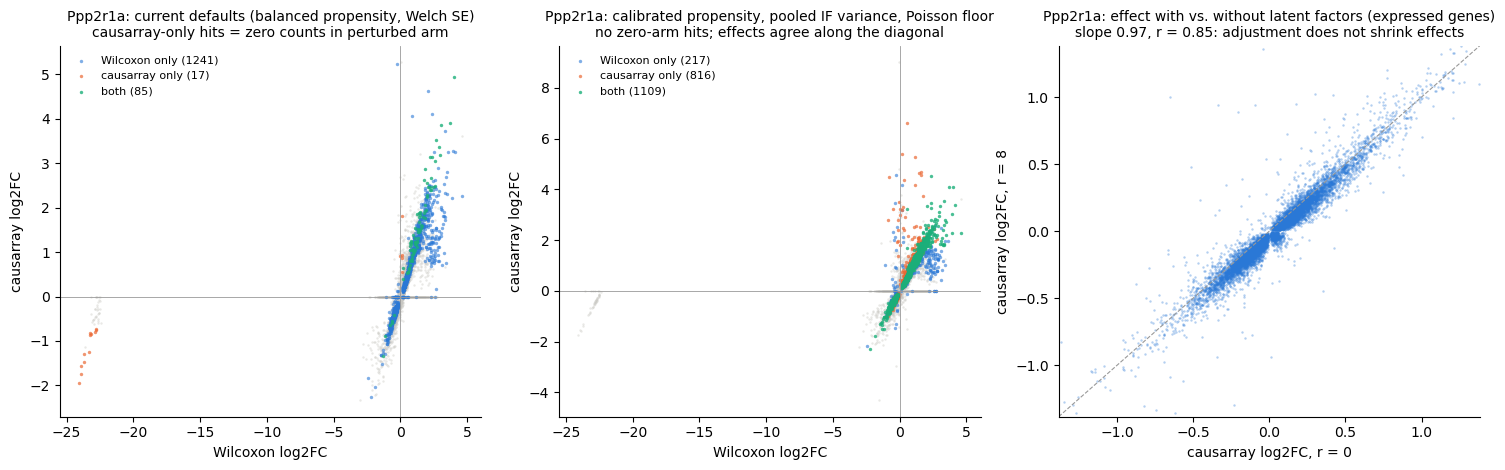

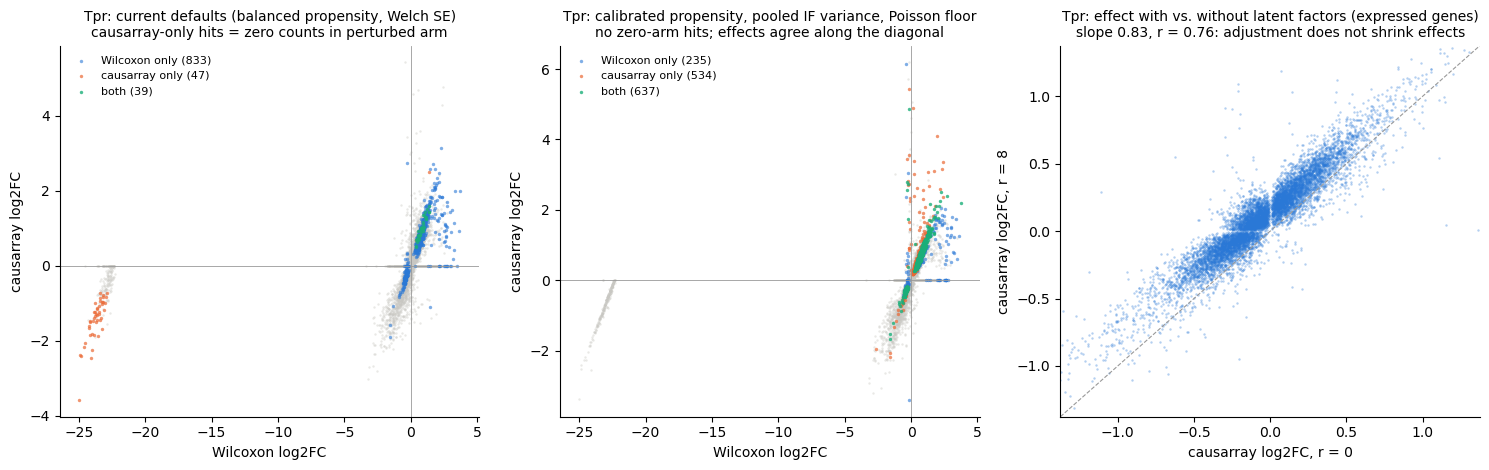

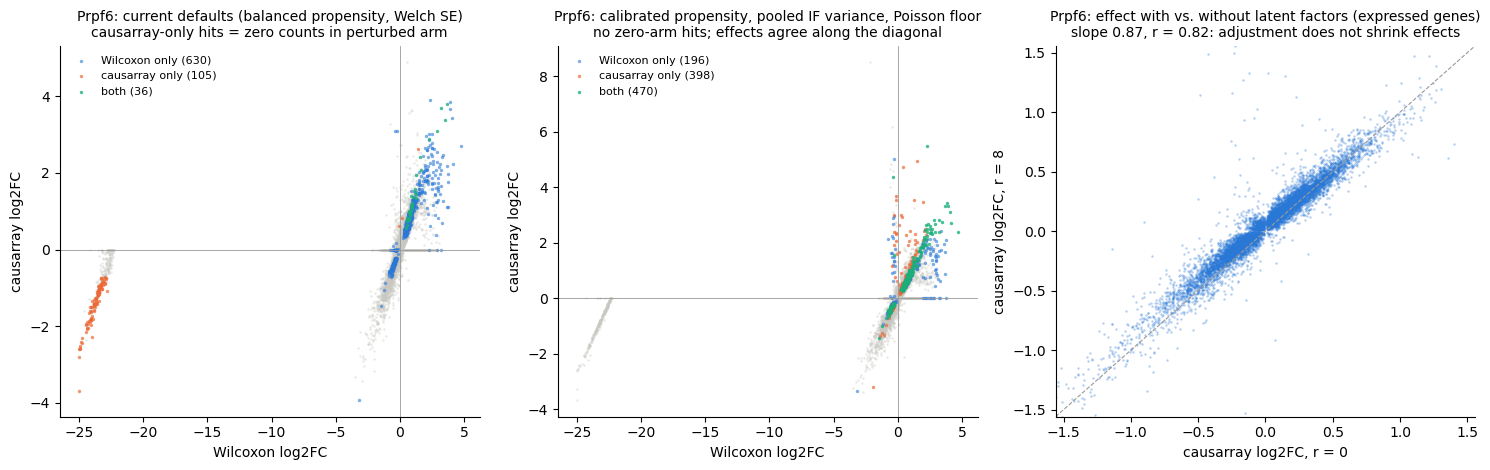

In [23]:
from matplotlib.lines import Line2D
BLUE, ORANGE, AQUA, GREY = '#2a78d6', '#eb6834', '#1baf7a', '#c8c7c2'

def _scatter(ax, x, y, ca_sig, w_sig, title, xl, yl):
    both = ca_sig & w_sig
    ax.scatter(x[~ca_sig & ~w_sig], y[~ca_sig & ~w_sig], s=3, c=GREY, alpha=.4, lw=0, rasterized=True)
    ax.scatter(x[w_sig & ~ca_sig], y[w_sig & ~ca_sig], s=6, c=BLUE, alpha=.6, lw=0, label=f'Wilcoxon only ({int((w_sig & ~ca_sig).sum())})')
    ax.scatter(x[ca_sig & ~w_sig], y[ca_sig & ~w_sig], s=6, c=ORANGE, alpha=.7, lw=0, label=f'causarray only ({int((ca_sig & ~w_sig).sum())})')
    ax.scatter(x[both], y[both], s=6, c=AQUA, alpha=.8, lw=0, label=f'both ({int(both.sum())})')
    ax.axhline(0, c='#999', lw=.6); ax.axvline(0, c='#999', lw=.6)
    ax.set_title(title, fontsize=10); ax.set_xlabel(xl); ax.set_ylabel(yl)
    ax.legend(fontsize=8, frameon=False, loc='upper left')
    for sp_ in ('top', 'right'): ax.spines[sp_].set_visible(False)

for trt in PERTS:
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.8))
    g = variants_a['r8_default_balanced_welch']; g = g[g['trt'] == trt]
    _scatter(axes[0], g['wilcox_logfc'].clip(-25, 6), g['log2fc'], g['padj'] < 0.05, g['w_sig'],
             f'{trt}: current defaults (balanced propensity, Welch SE)\ncausarray-only hits = zero counts in perturbed arm', 'Wilcoxon log2FC', 'causarray log2FC')
    g = variants_a['r8_calibrated_pooled_floor']; g = g[g['trt'] == trt]
    _scatter(axes[1], g['wilcox_logfc'].clip(-25, 6), g['log2fc'], g['padj'] < 0.05, g['w_sig'],
             f'{trt}: calibrated propensity, pooled IF variance, Poisson floor\nno zero-arm hits; effects agree along the diagonal', 'Wilcoxon log2FC', 'causarray log2FC')
    gj = j[(j['trt'] == trt) & ok]
    ax = axes[2]
    ax.scatter(gj['log2fc_r0'], gj['log2fc_r8'], s=3, c=BLUE, alpha=.35, lw=0, rasterized=True)
    lim = np.nanpercentile(np.abs(np.r_[gj['log2fc_r0'], gj['log2fc_r8']]), 99.5)
    ax.plot([-lim, lim], [-lim, lim], c='#999', lw=.8, ls='--'); ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
    sl = np.polyfit(gj['log2fc_r0'], gj['log2fc_r8'], 1)[0]; cc = np.corrcoef(gj['log2fc_r0'], gj['log2fc_r8'])[0, 1]
    ax.set_title(f'{trt}: effect with vs. without latent factors (expressed genes)\nslope {sl:.2f}, r = {cc:.2f}: adjustment does not shrink effects', fontsize=10)
    ax.set_xlabel('causarray log2FC, r = 0'); ax.set_ylabel('causarray log2FC, r = 8')
    for sp_ in ('top', 'right'): ax.spines[sp_].set_visible(False)
    plt.tight_layout()
    fig.savefig(os.path.join(INV_DIR, f'scarf_diagnosis_{trt}.png'), dpi=130)
    plt.show()

### Summary and open issues for the package

**What went wrong on SCARF**

1. *Zero-count perturbed arms are called as strong negative effects.* With
   68-227 cells per perturbation, chance zero arms are common for sparse
   genes. `LFC` floors the treated mean at `thres_diff`, takes the log, and the
   all-zero arm has ~0 empirical influence-function variance. This produced 83%
   of the discoveries and the entire "extreme negative DEG" cluster. The
   collaborators' Rule 1 (both arms ≥ 5 detections) was removing exactly these.
   Adamson never showed it because its perturbations have 700-1,900 cells.
2. *The default variance is not the variance of the estimator.*
   `class_weight='balanced'` propensity scores with the by-arm Welch formula
   inflate SEs ~2x for expressed genes (and are ~15x off in the oracle
   simulation). Real effects are estimated correctly and then not called. This
   is why r = 0 looked "more concordant with Wilcoxon" on slide 4: it is a
   power artifact of the SE, not evidence of over-adjustment.
3. *Latent factors are not the problem.* No factor differs between a
   perturbation and control by more than 0.05 SD; r = 8 vs r = 0 effect
   estimates agree (slope 0.82-0.96) and r = 8 has more power.

**Package-level issues surfaced here (for discussion)**

- `LFC` default `ps_class_weight='balanced'` + `usevar='unequal'`: the Welch
  formula `s0²/n0 + s1²/n1` assumes a two-sample difference of arm means, but
  the estimand averages pseudo-outcomes over all cells. With calibrated scores
  the pooled influence-function variance is the correct sandwich variance.
- With calibrated scores the default `ps_clip=(0.01, 0.99)` clips essentially
  every score for a treatment with prevalence below 1%.
- No model-based variance floor: an all-zero arm gets ~0 variance. The floor
  `1/(n1·mu1) + 1/(n0·mu0)` on the log scale (or treating a floored arm as
  non-estimable) fixes it without dropping genuine complete knockouts.
- `thres_min=0.01` and `thres_diff=0.01` are far below the count level at
  which single-cell inference is stable; `eps_var=1e-4` is on the relative
  scale and never binds.
- Even with calibrated + pooled + floor, very sparse genes (control mean
  < 0.05 counts/cell) remain positively skewed under the null with in-sample
  (`K=1`) nuisance fits. Candidates: a minimum-expression rule, cross-fitting
  (`K=2`), or a t reference with arm-size degrees of freedom.
- `backend='fast'` silently falls back to statsmodels when `crispyx` is not
  importable at import time; a warning would avoid unnoticed slow, slightly
  different fits.
- The propensity diagnostics (`summarize_propensity_scores`, AUC/overlap) are
  computed on the balanced-weight scores, so "poor overlap" partly reflects
  in-sample logistic overfitting with ~100 cases against thousands of controls.

### Full re-run with the causarray 0.0.10 defaults

The investigation above led to the 0.0.10 release: calibrated propensity
scores, the pooled influence-function variance with a small-sample
correction, a model-based variance floor, an expression threshold on observed
counts in the smaller arm, and a prevalence-aware propensity clip. The cell
below loads the full 58-perturbation re-run of this subset with those defaults
(`scarf_investigation/run_lfc_0.0.10.py`, cached GCATE factors, ~5.5 h;
`postprocess_0.0.10.py` applies the last two rules to the cached batches) and
compares it with the 0.0.9 result loaded at the top of this notebook and with
Wilcoxon.

,discoveries,zero counts in perturbed arm,fraction downregulated,perturbations with >= 50 hits,Wilcoxon hits recovered,Jaccard with Wilcoxon
version,,,,,,
0.0.9,1919,1588,0.83,14,252 / 7484 (3%),0.028
0.0.10,12346,0,0.31,39,5046 / 7484 (67%),0.341


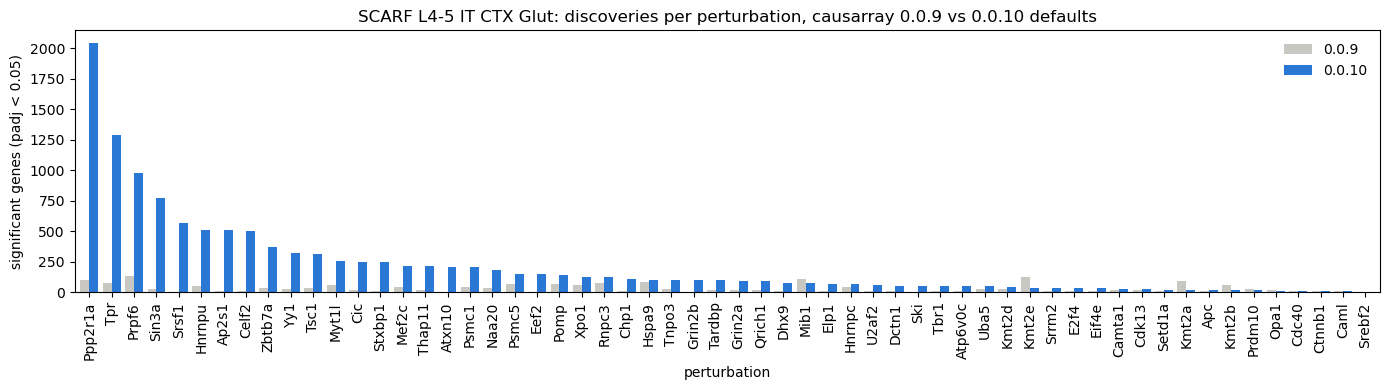

In [24]:
lfc10_path = os.path.join(INV_DIR, 'scarf-lfc-0.0.10.csv')
if not os.path.exists(lfc10_path):
    raise FileNotFoundError('run scarf_investigation/run_lfc_0.0.10.py and postprocess_0.0.10.py first')
df_res10 = pd.read_csv(lfc10_path)
sig10 = df_res10[df_res10['padj'] < 0.05]
cmp10 = df_res10[['trt', 'gene_names', 'tau', 'padj', 'count_treated']].merge(
    df_res[['trt', 'gene_names', 'tau', 'padj']].rename(columns={'tau': 'tau_009', 'padj': 'padj_009'}), on=['trt', 'gene_names']).merge(
    df_wc_full, on=['trt', 'gene_names'])
w_sig = (cmp10['wilcox_padj'] < comparison_q) & (cmp10['wilcox_logfc'] > -10)
rows = []
for label, col, tau_col in [('0.0.9', 'padj_009', 'tau_009'), ('0.0.10', 'padj', 'tau')]:
    cs = cmp10[col] < comparison_q
    s = cmp10[cs]
    rows.append({'version': label, 'discoveries': int(cs.sum()),
                 'zero counts in perturbed arm': int((s['count_treated'] == 0).sum()),
                 'fraction downregulated': round((s[tau_col] < 0).mean(), 2),
                 'perturbations with >= 50 hits': int((s['trt'].value_counts() >= 50).sum()),
                 'Wilcoxon hits recovered': f"{int((w_sig & cs).sum())} / {int(w_sig.sum())} ({100 * (w_sig & cs).sum() / w_sig.sum():.0f}%)",
                 'Jaccard with Wilcoxon': round((w_sig & cs).sum() / (w_sig | cs).sum(), 3)})
display(pd.DataFrame(rows).set_index('version'))

fig, ax = plt.subplots(figsize=(14, 4))
counts = pd.DataFrame({'0.0.9': cmp10[cmp10['padj_009'] < comparison_q]['trt'].value_counts(),
                       '0.0.10': sig10['trt'].value_counts()}).fillna(0).astype(int)
counts = counts.sort_values('0.0.10', ascending=False)
counts.plot.bar(ax=ax, width=0.8, color=['#c8c7c2', '#2a78d6'])
ax.set_ylabel('significant genes (padj < 0.05)'); ax.set_xlabel('perturbation')
ax.set_title('SCARF L4-5 IT CTX Glut: discoveries per perturbation, causarray 0.0.9 vs 0.0.10 defaults')
ax.legend(frameon=False); plt.tight_layout(); plt.show()